In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

c:\Users\Diego\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Random Forest — Attribute Effects via SHAP

This notebook measures the impact of each attribute on the outcome of the incident (`severity`) using **SHAP Global E[φ_k]** as the effect metric.

SHAP is computed on the **probability scale**, which ensures that its values are directly comparable to the **Average Marginal Effects (AMEs) from logistic regression**: both express the average change in P(severity = 1) attributed to each variable.

> **Warning — Random Forest pitfall:** as with XGBoost, the default `TreeExplainer` may return SHAP values on either the log-odds or probability scale depending on the SHAP version and configuration. For `RandomForestClassifier` in sklearn, the safest and most stable approach is to use `KernelExplainer` with an explicit `predict_proba` wrapper, ensuring that φ_k(i) are unequivocally on the probability scale.


In [2]:
url = "../../database/completo/df_completo_01_uf_br.csv"
df = pd.read_csv(url, sep=",", encoding="UTF-8")

In [3]:
df.head()

,dia_semana,km,sentido_via,condicao_metereologica,tipo_pista,uso_solo,intersecao_de_vias,reta,declive,feriado,turno,ano,mes,vel_max,distancia_radar_m,total_ocorrencia,gravidade,uf_br
0,1.0,0.076190,0,0.666667,1.0,0,0,1,0,0.5,1.0,2017,0.0,0.857143,0.080608,0.019027,1,0.678030
1,1.0,0.159184,0,0.666667,0.5,0,0,0,0,0.5,1.0,2017,0.0,1.000000,0.000167,0.086681,0,0.890152
2,1.0,0.295918,1,0.000000,0.5,1,0,1,0,0.5,1.0,2017,0.0,1.000000,0.000232,0.046512,1,0.234848
3,1.0,0.052381,1,0.666667,1.0,0,0,0,1,0.5,1.0,2017,0.0,0.857143,0.018193,0.002114,0,0.909091
4,1.0,0.127891,1,0.333333,0.5,1,0,1,0,0.5,1.0,2017,0.0,1.000000,0.016401,0.014799,0,0.280303


In [4]:
train_df = df[(df["ano"] >= 2017) & (df["ano"] <= 2024)]
test_df  = df[df["ano"] == 2025]

X_train = train_df.drop(columns=["gravidade", "ano"])
y_train = train_df["gravidade"]

X_test = test_df.drop(columns=["gravidade", "ano"])
y_test = test_df["gravidade"]

In [5]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' compensa o desbalanceamento de classes,
# ponderando cada observacao por n_amostras / (n_classes * n_amostras_classe).
# Equivalente ao scale_pos_weight do XGBoost e ao class_weight='balanced'
# da arvore de decisao.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n=== Metricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Metricas (Teste 2025) ===
Accuracy : 0.6683
Precision: 0.2132
Recall   : 0.5021
F1-score : 0.2993
AUC      : 0.6441

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.70      0.78     62109
           1       0.21      0.50      0.30     10201

    accuracy                           0.67     72310
   macro avg       0.55      0.60      0.54     72310
weighted avg       0.80      0.67      0.71     72310



In [7]:
# ============================================================
# SHAP na escala de PROBABILIDADE -- TreeExplainer
# ============================================================

X_background = shap.sample(X_train, 500, random_state=42)

explainer = shap.TreeExplainer(
    rf,
    data=X_background,
    model_output="probability",
    feature_perturbation="interventional"
)

print("Calculando SHAP values...")
X_test_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
n_obs      = len(X_test_sample)
n_features = X_test_sample.shape[1]

shap_values = explainer.shap_values(X_test_sample)
raw = np.array(shap_values)

print(f"Formato bruto retornado pelo TreeExplainer: {raw.shape}")
print(f"n_obs={n_obs}, n_features={n_features}")

# ------------------------------------------------------------
# Normaliza para shape (n_amostras, n_features) -- classe 1
# ------------------------------------------------------------
if isinstance(shap_values, list):
    # lista [classe_0, classe_1]
    shap_array = np.array(shap_values[1])
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[0] == 2:
    # (n_classes, n_amostras, n_features)
    shap_array = raw[1]
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[2] == 2:
    # (n_amostras, n_features, n_classes)
    shap_array = raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    # (n_amostras, n_features) ou (n_features, n_amostras) -- versoes recentes
    shap_array = raw
    expected_value = (
        explainer.expected_value[1]
        if hasattr(explainer.expected_value, "__len__")
        else explainer.expected_value
    )

# Garante orientacao (n_amostras, n_features):
# se o array chegou transposto (n_features, n_amostras), corrige.
if shap_array.shape == (n_features, n_obs):
    print("[AVISO] array transposto detectado -- corrigindo orientacao.")
    shap_array = shap_array.T

print(f"Formato dos SHAP values (classe 1): {shap_array.shape}")
print(f"Valor esperado (phi_0):             {expected_value:.6f}")

Calculando SHAP values...


100%|===================| 3997/4000 [04:26<00:00]        

Formato bruto retornado pelo TreeExplainer: (2000, 16, 2)
n_obs=2000, n_features=16
Formato dos SHAP values (classe 1): (2000, 16)
Valor esperado (phi_0):             0.466423


In [8]:
# ============================================================
# VALIDACAO da escala de probabilidade
# ============================================================
# Propriedade de eficiencia do SHAP:
#   phi_0 + sum_k(phi_k(i)) = P_hat(i) = P(gravidade=1 | X=x_i)
#
# Desvio baixo confirma que os valores SHAP estao na escala
# de probabilidade e sao comparaveis aos AMEs da regressao.

shap_reconstructed = expected_value + shap_array.sum(axis=1)
prob_real = rf.predict_proba(X_test_sample)[:, 1]

max_desvio  = np.abs(shap_reconstructed - prob_real).max()
mean_desvio = np.abs(shap_reconstructed - prob_real).mean()

print(f"phi_0 (valor esperado):                         {expected_value:.6f}")
print(f"Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   {max_desvio:.2e}")
print(f"Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   {mean_desvio:.2e}")

if max_desvio < 1e-3:
    print("\n[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.")
else:
    print("\n[ATENCAO] Desvio acima do esperado. Verifique a configuracao do explainer.")

phi_0 (valor esperado):                         0.466423
Desvio maximo  |phi_0 + sum(phi_k) - P_hat|:   5.68e-04
Desvio medio   |phi_0 + sum(phi_k) - P_hat|:   5.42e-06

[OK] SHAP na escala de probabilidade -- comparavel aos AMEs da regressao logistica.


In [9]:
# ============================================================
# SHAP GLOBAL -- E[phi_k]
# ============================================================
# Medida de efeito do Random Forest, na mesma escala e com a
# mesma interpretacao dos AMEs da regressao logistica:
#   "variacao media em P(gravidade=1) atribuida a variavel k"

# E[phi_k]: efeito medio com sinal -- use para comparar entre modelos
shap_global_mean = pd.Series(
    shap_array.mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_global_E[phi_k]"
)

# E[|phi_k|]: importancia absoluta -- use apenas para ranqueamento
# (perde o sinal do efeito; nao usar para comparacao com AME)
shap_global_abs = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_importancia_E[|phi_k|]"
)

resultado = pd.concat([shap_global_mean, shap_global_abs], axis=1)
resultado = resultado.sort_values(by="SHAP_importancia_E[|phi_k|]", ascending=False)

print("\n=== Impacto dos atributos na probabilidade do desfecho (Random Forest) ===")
print("SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade")
print("SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento")
print()
print(resultado.to_string())


=== Impacto dos atributos na probabilidade do desfecho (Random Forest) ===
SHAP_global_E[phi_k]        -> efeito medio com sinal, em unidades de probabilidade
SHAP_importancia_E[|phi_k|] -> importancia absoluta, para ranqueamento

                        SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
tipo_pista                          0.003358                     0.037167
vel_max                             0.005549                     0.033232
total_ocorrencia                    0.000089                     0.026792
uf_br                              -0.000253                     0.018654
distancia_radar_m                  -0.000979                     0.016608
turno                              -0.002999                     0.011952
condicao_metereologica              0.003180                     0.009821
uso_solo                            0.000003                     0.007156
dia_semana                         -0.000178                     0.006084
km                          

In [10]:
# ============================================================
# INTERPRETACAO DOS EFEITOS
# ============================================================
print("\n=== Interpretacao dos efeitos ===")
print("Variacao media em P(gravidade=1) atribuida a cada variavel.\n")

for var, row in resultado.iterrows():
    impacto     = row["SHAP_global_E[phi_k]"]
    importancia = row["SHAP_importancia_E[|phi_k|]"]

    if importancia < 1e-8:
        print(f"{var:35s}: SEM EFEITO")
    elif impacto > 0:
        print(f"{var:35s}: AUMENTA a probabilidade em +{impacto:.4f} (em media)")
    else:
        print(f"{var:35s}: REDUZ  a probabilidade em {impacto:.4f} (em media)")


=== Interpretacao dos efeitos ===
Variacao media em P(gravidade=1) atribuida a cada variavel.

tipo_pista                         : AUMENTA a probabilidade em +0.0034 (em media)
vel_max                            : AUMENTA a probabilidade em +0.0055 (em media)
total_ocorrencia                   : AUMENTA a probabilidade em +0.0001 (em media)
uf_br                              : REDUZ  a probabilidade em -0.0003 (em media)
distancia_radar_m                  : REDUZ  a probabilidade em -0.0010 (em media)
turno                              : REDUZ  a probabilidade em -0.0030 (em media)
condicao_metereologica             : AUMENTA a probabilidade em +0.0032 (em media)
uso_solo                           : AUMENTA a probabilidade em +0.0000 (em media)
dia_semana                         : REDUZ  a probabilidade em -0.0002 (em media)
km                                 : AUMENTA a probabilidade em +0.0001 (em media)
declive                            : AUMENTA a probabilidade em +0.0000 (em me

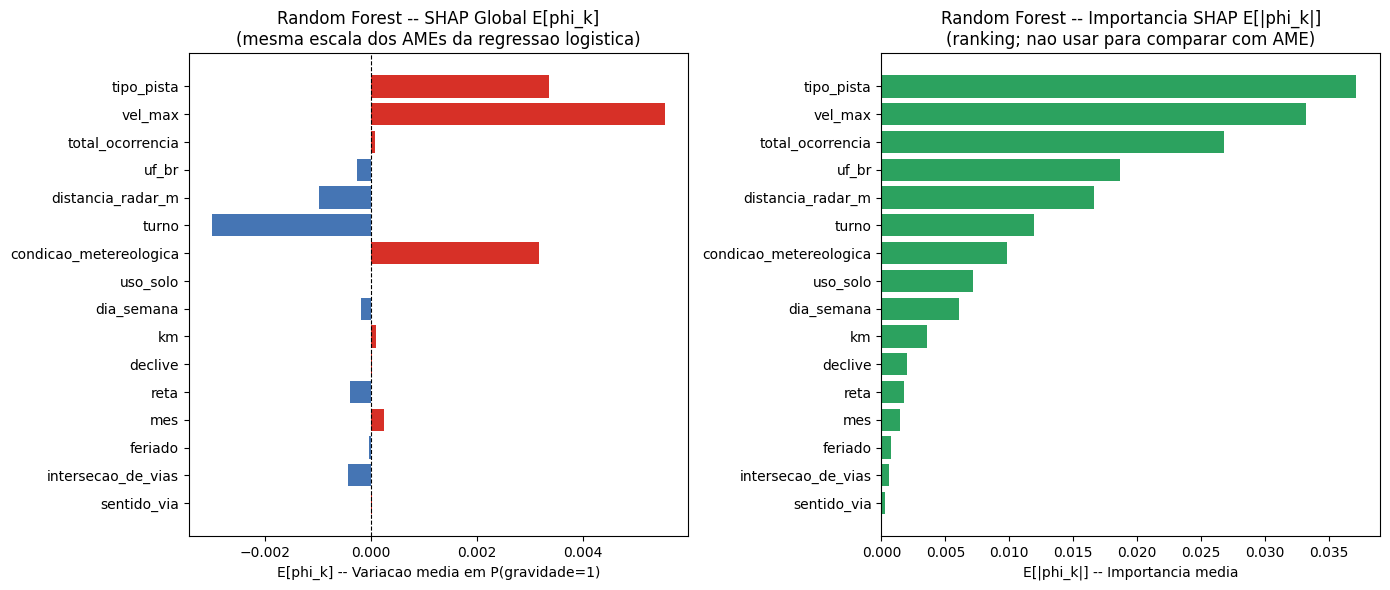

Grafico salvo em rf_shap_efeitos.png


In [11]:
# ============================================================
# VISUALIZACOES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: efeito medio com sinal (mesma leitura que AME)
cores = ['#d73027' if v > 0 else '#4575b4' for v in resultado["SHAP_global_E[phi_k]"]]
axes[0].barh(resultado.index, resultado["SHAP_global_E[phi_k]"], color=cores)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("E[phi_k] -- Variacao media em P(gravidade=1)")
axes[0].set_title("Random Forest -- SHAP Global E[phi_k]\n(mesma escala dos AMEs da regressao logistica)")
axes[0].invert_yaxis()

# Grafico 2: importancia absoluta (ranking)
axes[1].barh(resultado.index, resultado["SHAP_importancia_E[|phi_k|]"], color='#2ca25f')
axes[1].set_xlabel("E[|phi_k|] -- Importancia media")
axes[1].set_title("Random Forest -- Importancia SHAP E[|phi_k|]\n(ranking; nao usar para comparar com AME)")
axes[1].invert_yaxis()

plt.tight_layout()  
plt.savefig("rf_shap_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em rf_shap_efeitos.png")

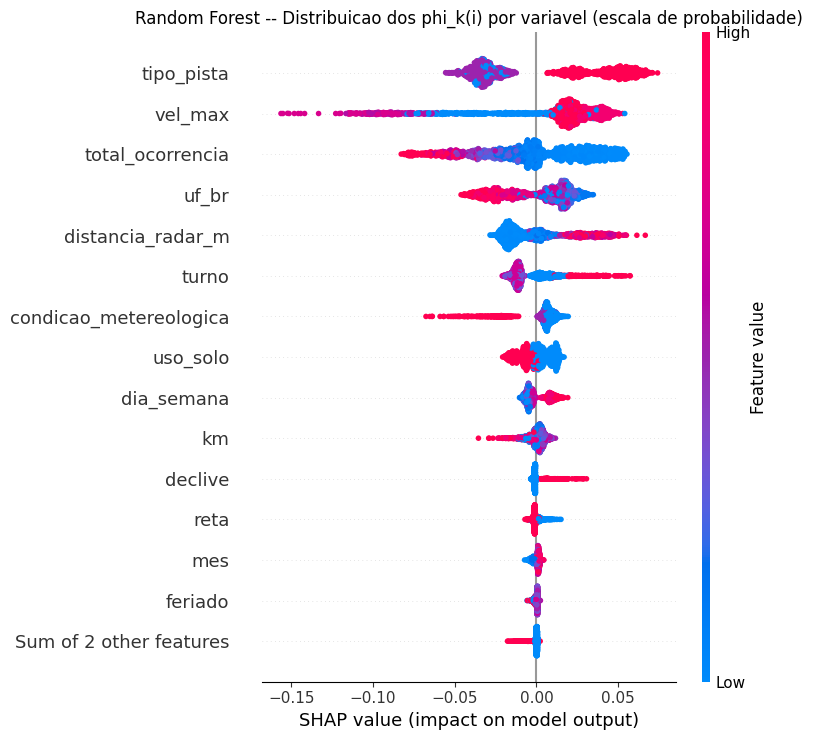

Beeswarm salvo em rf_shap_beeswarm.png


In [12]:
# ============================================================
# BEESWARM PLOT -- distribuicao local dos phi_k(i)
# ============================================================
# Revela heterogeneidade dos efeitos alem da media global.
# O eixo X esta em unidades de probabilidade.

shap_explanation = shap.Explanation(
    values=shap_array,
    base_values=expected_value,
    data=X_test_sample.values,
    feature_names=list(X_test_sample.columns)
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("Random Forest -- Distribuicao dos phi_k(i) por variavel (escala de probabilidade)")
plt.tight_layout()
plt.savefig("rf_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm salvo em rf_shap_beeswarm.png")

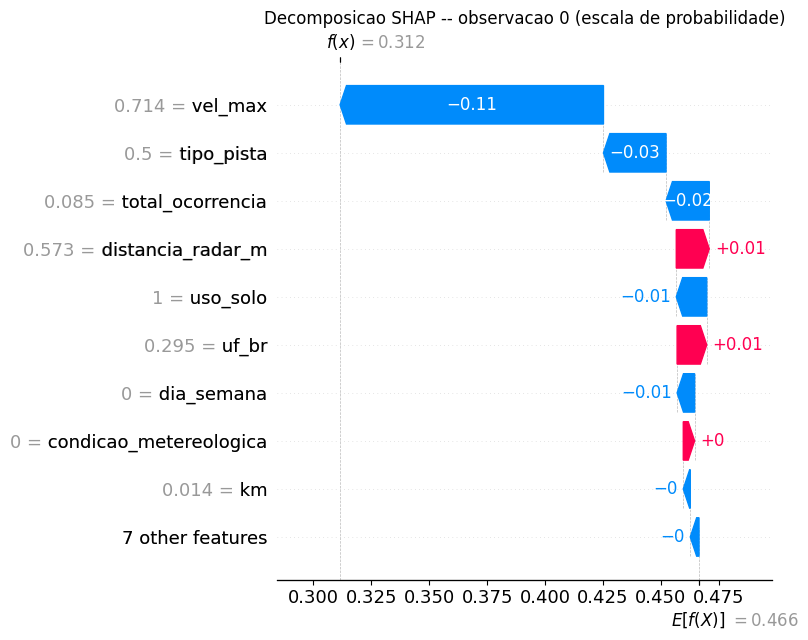

Waterfall salvo em rf_shap_waterfall.png


In [13]:
# ============================================================
# WATERFALL PLOT -- decomposicao de uma observacao individual
# ============================================================
# Mostra phi_0 + sum(phi_k(i)) = P_hat(i) para uma observacao.
# Util para auditar a escala e verificar a propriedade de eficiencia.

idx = 0  # altere para inspecionar outra observacao

plt.figure()
shap.plots.waterfall(shap_explanation[idx], show=False)
plt.title(f"Decomposicao SHAP -- observacao {idx} (escala de probabilidade)")
plt.tight_layout()
plt.savefig("rf_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall salvo em rf_shap_waterfall.png")